In [1]:
from retriever_v2.base import Document
from retriever_v2.bm25 import BM25Retriever
from retriever_v2.utils import INDEX_DIR

import pandas as pd

In [2]:
docs = [
    Document(file.stem.split("_")[0], file.read_text(encoding="utf-8"))
    for file in (INDEX_DIR / "docs").glob("*.txt")
]

In [3]:
retriever = BM25Retriever(documents=docs)

100%|██████████| 12976/12976 [01:19<00:00, 163.35it/s]


In [5]:
test_queries = (
    pd.read_csv(INDEX_DIR / "test_scores.csv")
    .rename(columns={"Unnamed: 0": "doc_id"})
    .set_index("doc_id")
)

In [6]:
from sklearn.metrics import ndcg_score

In [24]:
# grid search over b and k1
res = []

for b in [0.75, 1, 1.25, 1.5]:
    for k1 in [1.75, 2, 2.25, 2.5]:
        retriever.set_params(b=b, k1=k1)

        for query in test_queries.columns:
            scores_df = pd.DataFrame(retriever.score(query)).set_index("doc_id")
            scores_df["gold_standard"] = test_queries[query][scores_df.index]
            score = ndcg_score(
                [scores_df["gold_standard"].values], [scores_df["score"].values]
            )
            res.append({"b": b, "k1": k1, "query": query, "score": score})

In [25]:
res_df = pd.DataFrame(res)

In [26]:
import seaborn as sns

<Axes: xlabel='k1', ylabel='b'>

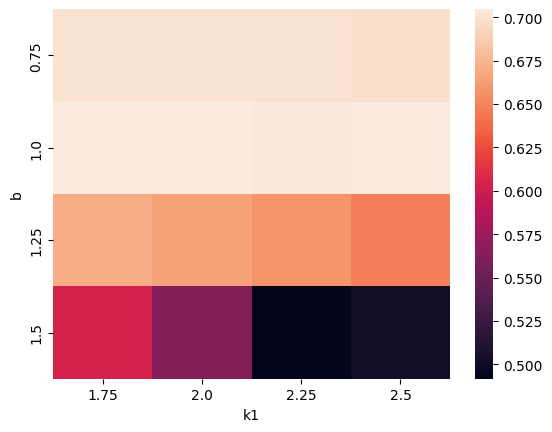

In [27]:
sns.heatmap(res_df.groupby(["b", "k1"])["score"].mean().unstack())

In [29]:
res_df.groupby(["b", "k1"])["score"].mean().sort_values(ascending=False)

b     k1  
1.00  2.00    0.704619
      1.75    0.704573
      2.50    0.703894
      2.25    0.703679
0.75  1.75    0.699229
      2.25    0.698937
      2.00    0.698861
      2.50    0.698456
1.25  1.75    0.670089
      2.00    0.664287
      2.25    0.657821
      2.50    0.647999
1.50  1.75    0.603838
      2.00    0.562827
      2.50    0.502509
      2.25    0.491759
Name: score, dtype: float64

In [33]:
results = {}

for query in test_queries.columns:
    scores_df = pd.DataFrame(retriever.score(query)).set_index("doc_id")
    scores_df["gold_standard"] = test_queries[query][scores_df.index]
    score = ndcg_score([scores_df["gold_standard"].values], [scores_df["score"].values])
    results[query] = score

<Axes: >

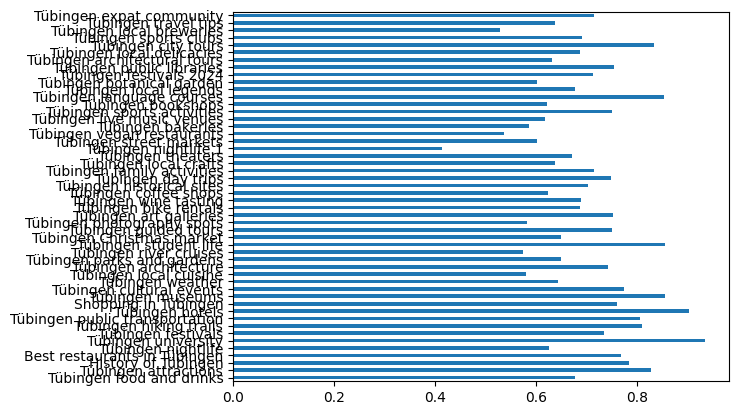

In [41]:
pd.Series(results).plot(kind="barh")

In [39]:
!pip install matplotlib

     ---------------------------------------- 0.0/165.9 kB ? eta -:--:--
     -------------------------------------- 165.9/165.9 kB 5.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.4/8.0 MB 7.8 MB/s eta 0:00:01
   --- ------------------------------------ 0.7/8.0 MB 7.8 MB/s eta 0:00:01
   ----- ---------------------------------- 1.1/8.0 MB 7.9 MB/s eta 0:00:01
   ------- -------------------------------- 1.5/8.0 MB 8.0 MB/s eta 0:00:01
   --------- ------------------------------ 1.9/8.0 MB 8.0 MB/s eta 0:00:01
   ----------- ---------------------------- 2.2/8.0 MB 7.9 MB/s eta 0:00:01
   ------------- -------------------------- 2.6/8.0 MB 7.9 MB/s eta 0:00:01
   -------------- ------------------------- 3.0/8.0 MB 7.9 MB/s eta 0:00:01
   ---------------- ----------------------- 3.4/8.0 MB 7.9 MB/s eta 0:00:01
   ------------------ --------------------- 3.7/8.0 MB 7.9 MB/s eta 0:00:01
   ---------------


[notice] A new release of pip is available: 24.1.1 -> 24.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
